In [1]:
import numpy as np                      # For numerical operations
import pandas as pd                     # For handling CSV dataset
import matplotlib.pyplot as plt         # For plotting graphs

from sklearn.preprocessing import StandardScaler        # For feature scaling
from sklearn.cluster import KMeans                     # K-Means algorithm
from sklearn.cluster import AgglomerativeClustering    # Hierarchical clustering
from sklearn.metrics import silhouette_score           # Cluster quality metric
from sklearn.metrics import davies_bouldin_score       # Cluster separation metric
from scipy.cluster.hierarchy import dendrogram         # For dendrogram plot
from scipy.cluster.hierarchy import linkage            # For linkage matrix

In [3]:
df = pd.read_csv("boston.csv")   # Read dataset from CSV file

print("Dataset Loaded Successfully")
print(df.head())                         # Display first 5 rows


Dataset Loaded Successfully
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [6]:
# Select only numeric columns required for clustering
X = df[['TAX', 'B', 'MEDV']]


In [7]:
print("\nSelected Features:")
print(X.head())


Selected Features:
     TAX       B  MEDV
0  296.0  396.90  24.0
1  242.0  396.90  21.6
2  242.0  392.83  34.7
3  222.0  394.63  33.4
4  222.0  396.90  36.2


In [8]:
scaler = StandardScaler()                # Create StandardScaler object
X_scaled = scaler.fit_transform(X)
   # Fit and transform data (mean=0, std=1)

print("\nData Standardized Successfully")


Data Standardized Successfully


In [9]:
X_scaled

array([[-0.66660821,  0.44105193,  0.15968566],
       [-0.98732948,  0.44105193, -0.10152429],
       [-0.98732948,  0.39642699,  1.32424667],
       ...,
       [-0.80321172,  0.44105193,  0.14880191],
       [-0.80321172,  0.4032249 , -0.0579893 ],
       [-0.80321172,  0.44105193, -1.15724782]])

In [10]:
# K-MEANS CLUSTERING
# ============================================================

wcss = []                                # Empty list to store WCSS values
sil_scores = []                          # Empty list to store Silhouette scores
K_range = range(2, 11)                   # Try K values from 2 to 10

# Loop through different K values
for k in K_range:

    kmeans = KMeans(
        n_clusters=k,                    # Number of clusters
        init='k-means++',                # Smart centroid initialization
        n_init=20,                       # Run algorithm 20 times
        random_state=42                  # Fix randomness
    )

    labels = kmeans.fit_predict(X_scaled)  # Fit model and predict clusters

    wcss.append(kmeans.inertia_)           # Store WCSS (inertia_)

    sil = silhouette_score(X_scaled, labels)  # Compute silhouette score
    sil_scores.append(sil)                     # Store silhouette score

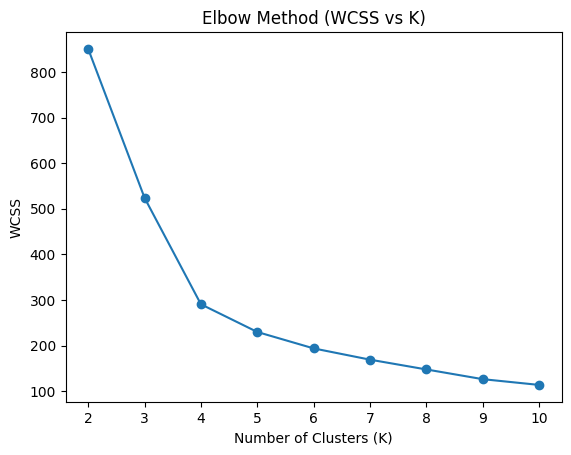

In [11]:
# -------------------------------
# Step 4: Plot Elbow Curve
# -------------------------------

plt.figure()                               # Create new figure
plt.plot(K_range, wcss, marker='o')        # Plot K vs WCSS
plt.title("Elbow Method (WCSS vs K)")      # Graph title
plt.xlabel("Number of Clusters (K)")       # X-axis label
plt.ylabel("WCSS")                         # Y-axis label
plt.show()                                 # Display plot

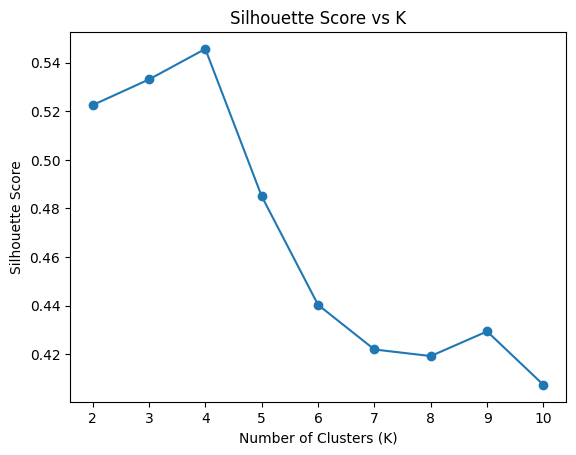

In [12]:
# -------------------------------
# Step 5: Plot Silhouette Curve
# -------------------------------

plt.figure()                               # Create new figure
plt.plot(K_range, sil_scores, marker='o')  # Plot K vs Silhouette score
plt.title("Silhouette Score vs K")         # Graph title
plt.xlabel("Number of Clusters (K)")       # X-axis label
plt.ylabel("Silhouette Score")             # Y-axis label
plt.show()                                 # Display plot


In [13]:
# -------------------------------
# Step 6: Determine Optimal K
# -------------------------------

optimal_k = K_range[np.argmax(sil_scores)]  # Select K with highest silhouette

print("\nOptimal Number of Clusters:", optimal_k)



Optimal Number of Clusters: 4


In [14]:
# -------------------------------
# Step 7: Train Final KMeans Model
# -------------------------------

final_kmeans = KMeans(
    n_clusters=optimal_k,                 # Use optimal K
    init='k-means++',                     # Smart initialization
    n_init=20,                            # 20 runs
    random_state=42                       # Fix seed
)

kmeans_labels = final_kmeans.fit_predict(X_scaled)  # Fit and predict clusters

In [15]:
# -------------------------------
# Step 8: Evaluate KMeans
# -------------------------------

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)  # Silhouette score
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)      # DB score

print("\nKMeans Evaluation Results:")
print("Silhouette Score:", kmeans_silhouette)
print("Davies-Bouldin Score:", kmeans_db)



KMeans Evaluation Results:
Silhouette Score: 0.5457009456386945
Davies-Bouldin Score: 0.6264240880647313


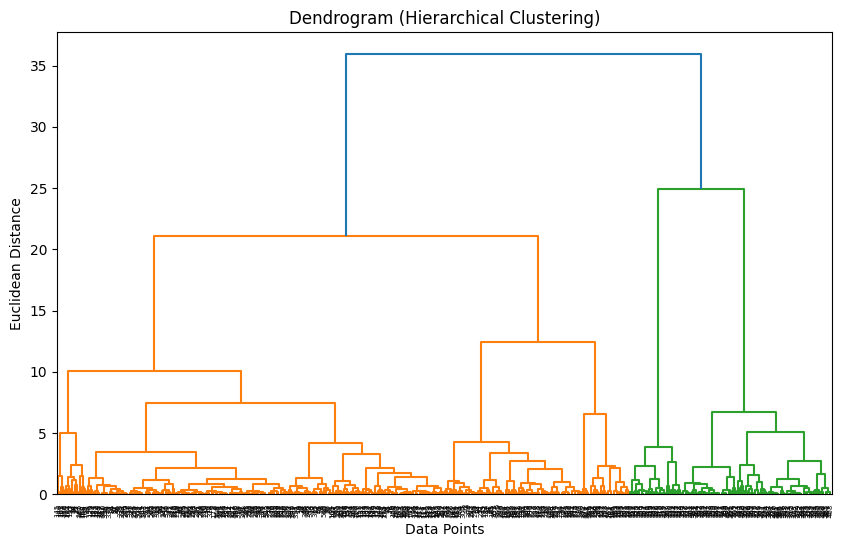

In [17]:
# ============================================================
# DENDROGRAM VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))                # Create large figure

linkage_matrix = linkage(X_scaled, method='ward')  # Compute linkage matrix

dendrogram(linkage_matrix)                 # Plot dendrogram

plt.title("Dendrogram (Hierarchical Clustering)")  # Title
plt.xlabel("Data Points")                  # X-axis label
plt.ylabel("Euclidean Distance")           # Y-axis label
plt.show()                                 # Display dendrogram


In [18]:
# ============================================================
# AGGLOMERATIVE CLUSTERING
# ============================================================

agglo_model = AgglomerativeClustering(
    n_clusters=optimal_k,                  # Use same optimal K
    linkage='ward'                         # Ward linkage method
)

agglo_labels = agglo_model.fit_predict(X_scaled)  # Fit and predict clusters


In [19]:
# -------------------------------
# Step 9: Evaluate Agglomerative
# -------------------------------

agglo_silhouette = silhouette_score(X_scaled, agglo_labels)  # Silhouette
agglo_db = davies_bouldin_score(X_scaled, agglo_labels)      # DB score

print("\nAgglomerative Clustering Results:")
print("Silhouette Score:", agglo_silhouette)
print("Davies-Bouldin Score:", agglo_db)


Agglomerative Clustering Results:
Silhouette Score: 0.4842740123091334
Davies-Bouldin Score: 0.6919587493739946
